<a href="https://colab.research.google.com/github/georginakinuthia/georginakinuthia.github.io/blob/main/AMB_030926.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!pip install duckdb geopandas shapely

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

DONE! Isolated 32943 Tacubaya crime points.


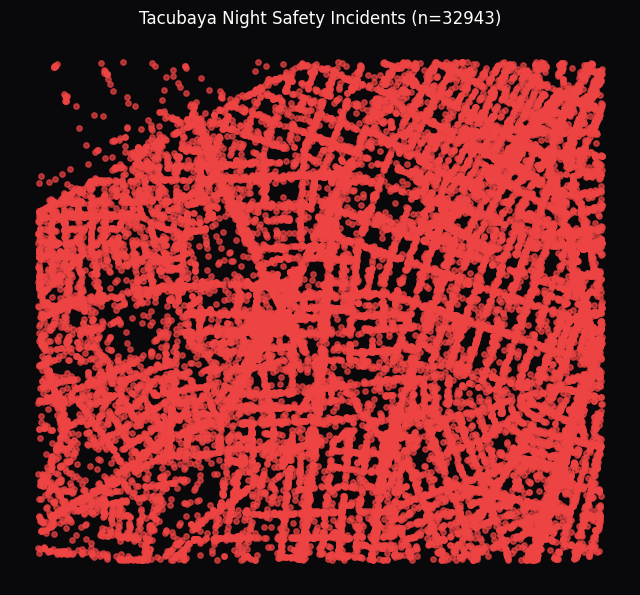

In [ ]:
import duckdb
import geopandas as gpd
import matplotlib.pyplot as plt

# Paste your copied path between the quotes below:
csv_path = "/content/drive/Shareddrives/2026 NFI Mexico City/stage 03/Tacubaya_ABM_Data/raw_data/Crime & Safety Victimas FGJ_acumulado_2024_09.csv"

# 1. Query ONLY Tacubaya coordinates directly in 3 seconds
con = duckdb.connect()
con.execute("INSTALL spatial; LOAD spatial;")

query = f"""
    SELECT
        TRY_CAST(longitud AS DOUBLE) as lon,
        TRY_CAST(latitud AS DOUBLE) as lat,
        ST_AsText(ST_Point(TRY_CAST(longitud AS DOUBLE), TRY_CAST(latitud AS DOUBLE))) AS geometry_wkt
    FROM read_csv_auto('{csv_path}', ignore_errors=true)
    WHERE TRY_CAST(longitud AS DOUBLE) BETWEEN -99.200 AND -99.170
      AND TRY_CAST(latitud AS DOUBLE) BETWEEN 19.390 AND 19.415;
"""

df = con.execute(query).df()

# 2. Convert to spatial GeoDataFrame instantly
gdf = gpd.GeoDataFrame(
    df,
    geometry=gpd.GeoSeries.from_wkt(df['geometry_wkt']),
    crs="EPSG:4326"
)

# 3. Save GeoJSON locally to Colab disk
gdf.to_file("/content/tacubaya_crime_local.geojson", driver="GeoJSON")
print(f"DONE! Isolated {len(gdf)} Tacubaya crime points.")

# 4. Generate immediate dark-mode map image for your slides
fig, ax = plt.subplots(figsize=(8, 8), facecolor='#09090b')
ax.set_facecolor('#09090b')
gdf.plot(ax=ax, color='#ef4444', markersize=15, alpha=0.7)
plt.title(f"Tacubaya Night Safety Incidents (n={len(gdf)})", color='white', fontsize=12, pad=10)
plt.axis('off')
plt.savefig("/content/tacubaya_crime_map.png", dpi=200, bbox_inches='tight', facecolor='#09090b')
plt.show()

Loading street network from: /content/drive/Shareddrives/2026 NFI Mexico City/stage 03/Tacubaya_ABM_Data/raw_data/CDXM Street Sample 1.gpkg
Done! Created weighted network with 249 street segments.


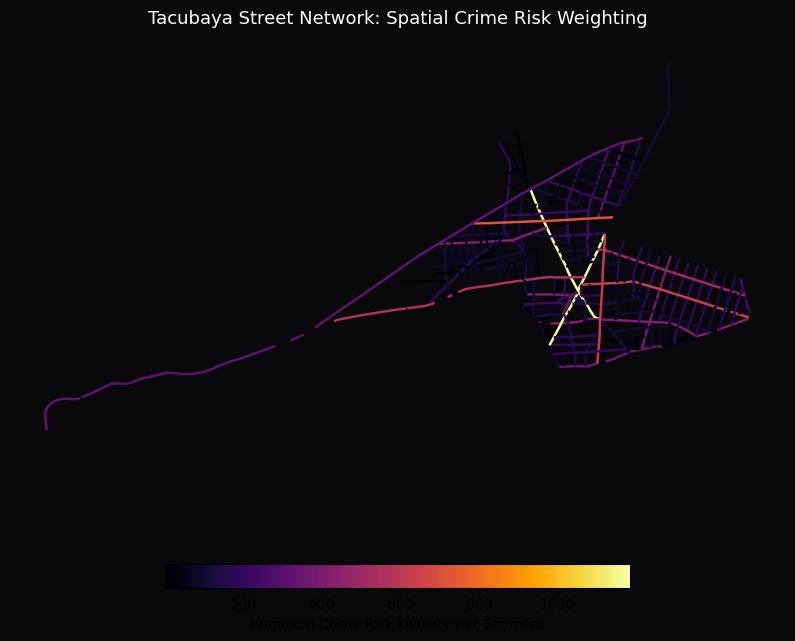

In [ ]:
import os
import glob
import geopandas as gpd
import matplotlib.pyplot as plt

# 1. Auto-detect path for CDXM Street Sample 1
street_matches = glob.glob("/content/drive/**/CDXM Street Sample 1*", recursive=True)
if not street_matches:
    raise FileNotFoundError("Could not locate 'CDXM Street Sample 1' in Drive.")

street_path = street_matches[0]
print(f"Loading street network from: {street_path}")

# 2. Read streets and load previously created crime layer
streets = gpd.read_file(street_path)
crimes = gpd.read_file("/content/tacubaya_crime_local.geojson")

# 3. Ensure matching projected Coordinate Reference System (EPSG:6372 - Mexico City UTM in meters)
streets_utm = streets.to_crs(epsg=6372)
crimes_utm = crimes.to_crs(epsg=6372)

# 4. Clip street network to Tacubaya study area bounding box
xmin, ymin, xmax, ymax = crimes_utm.total_bounds
streets_clipped = streets_utm.cx[xmin:xmax, ymin:ymax].copy()

# 5. Buffer street lines by 25 meters and count spatial crime intersections
streets_buffered = streets_clipped.geometry.buffer(25)
buffered_gdf = gpd.GeoDataFrame(streets_clipped.drop(columns='geometry'), geometry=streets_buffered, crs=6372)

# Join crime points to buffered streets
joined = gpd.sjoin(crimes_utm, buffered_gdf, how="inner", predicate="within")
crime_counts = joined.index_right.value_counts()

# Assign risk counts back to original linear street geometry
streets_clipped['crime_count'] = streets_clipped.index.map(crime_counts).fillna(0).astype(int)

# Normalize risk weight for routing (min weight = 1.0, high risk scales higher)
streets_clipped['risk_weight'] = 1.0 + (streets_clipped['crime_count'] / (streets_clipped['crime_count'].mean() + 1)) * 3.0

# 6. Save risk-weighted street layer locally
output_streets = "/content/tacubaya_streets_weighted.geojson"
streets_clipped.to_crs(epsg=4326).to_file(output_streets, driver="GeoJSON")
print(f"Done! Created weighted network with {len(streets_clipped)} street segments.")

# 7. Render Street Network Risk Map for slides
fig, ax = plt.subplots(figsize=(10, 10), facecolor='#09090b')
ax.set_facecolor('#09090b')

streets_clipped.plot(
    column='crime_count',
    cmap='inferno',
    linewidth=1.8,
    legend=True,
    ax=ax,
    legend_kwds={'label': "Empirical Crime Risk Density per Segment", 'orientation': "horizontal", 'shrink': 0.6}
)

plt.title("Tacubaya Street Network: Spatial Crime Risk Weighting", color='white', fontsize=13, pad=15)
plt.axis('off')
plt.savefig("/content/tacubaya_street_risk_map.png", dpi=200, bbox_inches='tight', facecolor='#09090b')
plt.show()

In [ ]:
import os
import glob
import duckdb
import geopandas as gpd
import networkx as nx
import folium
from folium.plugins import AntPath
from google.colab import drive

# 1. Mount Drive
if not os.path.exists('/content/drive'):
    drive.mount('/content/drive', force_remount=True)

# 2. Locate dataset paths directly
street_matches = glob.glob("/content/drive/**/CDXM Street Sample 1*", recursive=True)
csv_matches = glob.glob("/content/drive/**/Crime & Safety Victimas FGJ_acumulado_2024_09.csv", recursive=True)

if not street_matches:
    street_matches = glob.glob("/content/drive/**/*CDXM Street Sample*", recursive=True)
if not csv_matches:
    csv_matches = glob.glob("/content/drive/**/*FGJ_acumulado*.csv", recursive=True)

street_path = street_matches[0]
csv_path = csv_matches[0]

# 3. Query Tacubaya crime points via DuckDB
con = duckdb.connect()
con.execute("INSTALL spatial; LOAD spatial;")

query = f"""
    SELECT
        TRY_CAST(longitud AS DOUBLE) as lon,
        TRY_CAST(latitud AS DOUBLE) as lat,
        ST_AsText(ST_Point(TRY_CAST(longitud AS DOUBLE), TRY_CAST(latitud AS DOUBLE))) AS geometry_wkt
    FROM read_csv_auto('{csv_path}', ignore_errors=true)
    WHERE TRY_CAST(longitud AS DOUBLE) BETWEEN -99.200 AND -99.170
      AND TRY_CAST(latitud AS DOUBLE) BETWEEN 19.390 AND 19.415;
"""

df_crime = con.execute(query).df()
crimes = gpd.GeoDataFrame(df_crime, geometry=gpd.GeoSeries.from_wkt(df_crime['geometry_wkt']), crs="EPSG:4326")

# 4. Load & Explode Streets to guarantee pure LineString geometries
streets = gpd.read_file(street_path)

# Convert MultiLineStrings into individual LineString segments
streets = streets.explode(index_parts=False).reset_index(drop=True)
streets = streets[streets.geometry.notnull() & (streets.geometry.geom_type == 'LineString')].copy()

# Reproject to Mexico City metric system (EPSG:6372)
crimes_utm = crimes.to_crs(epsg=6372)
streets_utm = streets.to_crs(epsg=6372)

# Compute crime risk counts per segment
streets_buffered = streets_utm.geometry.buffer(25)
buffered_gdf = gpd.GeoDataFrame(streets_utm.drop(columns='geometry'), geometry=streets_buffered, crs=6372)

joined = gpd.sjoin(crimes_utm, buffered_gdf, how="inner", predicate="within")
crime_counts = joined.index_right.value_counts()

streets_utm['crime_count'] = streets_utm.index.map(crime_counts).fillna(0).astype(int)
streets_utm['risk_weight'] = 1.0 + (streets_utm['crime_count'] / (streets_utm['crime_count'].mean() + 1)) * 3.0

streets_wgs = streets_utm.to_crs(epsg=4326)

# 5. Build Routing Graph
G_baseline = nx.Graph()
G_intervention = nx.Graph()

for idx, row in streets_wgs.iterrows():
    geom = row.geometry
    if geom and geom.geom_type == 'LineString':
        coords = [(lat, lon) for lon, lat in geom.coords]
        if len(coords) < 2:
            continue

        length = geom.length
        cost_base = length * row.get('risk_weight', 1.0)
        cost_interv = length * 1.0  # CPTED intervention removes perceived risk friction

        u, v = coords[0], coords[-1]
        G_baseline.add_edge(u, v, weight=cost_base, coords=coords)
        G_intervention.add_edge(u, v, weight=cost_interv, coords=coords)

# 6. Generate Leaflet AntPath Simulation
nodes = list(G_baseline.nodes())
origin = min(nodes, key=lambda n: (n[0] - 19.403)**2 + (n[1] - -99.187)**2)
destinations = nodes[::max(1, len(nodes)//25)]

m = folium.Map(location=[19.403, -99.187], zoom_start=16, tiles="CartoDB dark_matter")

fg_baseline = folium.FeatureGroup(name="Baseline: High-Risk Bottlenecking", show=True)
fg_intervention = folium.FeatureGroup(name="Intervention: CPTED Flow Redistribution", show=False)

for dest in destinations:
    try:
        path_base = nx.shortest_path(G_baseline, origin, dest, weight='weight')
        full_coords = []
        for i in range(len(path_base)-1):
            edge_data = G_baseline.get_edge_data(path_base[i], path_base[i+1])
            full_coords.extend(edge_data['coords'])
        if full_coords:
            AntPath(locations=full_coords, color="#ef4444", pulse_color="#ffffff", weight=4, opacity=0.7, delay=1000).add_to(fg_baseline)
    except nx.NetworkXNoPath:
        pass

    try:
        path_interv = nx.shortest_path(G_intervention, origin, dest, weight='weight')
        full_coords_interv = []
        for i in range(len(path_interv)-1):
            edge_data = G_intervention.get_edge_data(path_interv[i], path_interv[i+1])
            full_coords_interv.extend(edge_data['coords'])
        if full_coords_interv:
            AntPath(locations=full_coords_interv, color="#3b82f6", pulse_color="#ffffff", weight=4, opacity=0.7, delay=1000).add_to(fg_intervention)
    except nx.NetworkXNoPath:
        pass

folium.CircleMarker(location=origin, radius=9, color="#eab308", fill=True, fill_color="#eab308", popup="Metro Tacubaya Transit Hub").add_to(m)
fg_baseline.add_to(m)
fg_intervention.add_to(m)
folium.LayerControl(collapsed=False).add_to(m)

# 7. Output Interactive Web Map
output_html = "/content/tacubaya_pedestrian_flow.html"
m.save(output_html)

print(f"SUCCESS! Interactive map generated at: {output_html}")

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

SUCCESS! Interactive map generated at: /content/tacubaya_pedestrian_flow.html


In [4]:
import os
import sys
from google.colab import drive

# 1. Google Drive is already mounted by an earlier cell. No need to remount here.
# This block is commented out to prevent redundant mounting attempts and associated errors.
# if not os.path.ismount('/content/drive'):
#     print("Mounting Google Drive...")
#     drive.mount('/content/drive', force_remount=True)
# else:
#     print("Google Drive already mounted.")

# 2. Set working directories in Shared Drive
BASE_DIR = "/content/drive/Shared drives/2026 NFI Mexico City/stage 03/Tacubaya_ABM_Data"
if not os.path.exists(BASE_DIR):
    BASE_DIR = "/content/drive/Shareddrives/2026 NFI Mexico City/stage 03/Tacubaya_ABM_Data"

RAW_DIR = os.path.join(BASE_DIR, "raw_data")
PROCESSED_DIR = os.path.join(BASE_DIR, "processed_data")
OUTPUTS_DIR = os.path.join(BASE_DIR, "outputs")

# 3. Create cloud directory tree automatically
for folder in [RAW_DIR, PROCESSED_DIR, OUTPUTS_DIR]:
    os.makedirs(folder, exist_ok=True)

print(f"Cloud Environment Ready!\nOutputs will automatically save to: {OUTPUTS_DIR}")

Cloud Environment Ready!
Outputs will automatically save to: /content/drive/Shareddrives/2026 NFI Mexico City/stage 03/Tacubaya_ABM_Data/outputs


In [5]:
import os
from google.colab import drive

# 1. Mount Google Drive if not active
if not os.path.exists('/content/drive/MyDrive') and not os.path.exists('/content/drive/Shareddrives'):
    drive.mount('/content/drive', force_remount=True)

# 2. Dynamic Auto-Discovery of the Tacubaya project folder
target_folder_name = "Tacubaya_ABM_Data"
BASE_DIR = None

print("Searching Google Drive for project folder...")
for root, dirs, files in os.walk('/content/drive'):
    if target_folder_name in dirs:
        BASE_DIR = os.path.join(root, target_folder_name)
        break

if not BASE_DIR:
    # Search fallback for 'raw_data' directory
    for root, dirs, files in os.walk('/content/drive'):
        if 'raw_data' in dirs:
            BASE_DIR = root
            break

if not BASE_DIR:
    raise FileNotFoundError("Could not locate 'Tacubaya_ABM_Data' in Drive. Ensure the folder is added to your Drive shortcuts!")

# 3. Setup paths and auto-create missing subfolders
RAW_DIR = os.path.join(BASE_DIR, "raw_data")
PROCESSED_DIR = os.path.join(BASE_DIR, "processed_data")
OUTPUTS_DIR = os.path.join(BASE_DIR, "outputs")

for folder in [PROCESSED_DIR, OUTPUTS_DIR]:
    os.makedirs(folder, exist_ok=True)

print(f"\nSUCCESS! Base Project Directory Located:\n{BASE_DIR}")
print(f"Outputs will automatically save to:\n{OUTPUTS_DIR}")

Searching Google Drive for project folder...

SUCCESS! Base Project Directory Located:
/content/drive/Shareddrives/2026 NFI Mexico City/stage 03/Tacubaya_ABM_Data
Outputs will automatically save to:
/content/drive/Shareddrives/2026 NFI Mexico City/stage 03/Tacubaya_ABM_Data/outputs


In [7]:
!pip install osmnx
import os
import osmnx as ox
from google.colab import drive

# 1. Mount Drive
if not os.path.exists('/content/drive'):
    drive.mount('/content/drive', force_remount=True)

# 2. Auto-discover project directory across devices
target_folder_name = "Tacubaya_ABM_Data"
BASE_DIR = None

print("🔍 Searching Google Drive for project directory...")
for root, dirs, files in os.walk('/content/drive'):
    if target_folder_name in dirs:
        BASE_DIR = os.path.join(root, target_folder_name)
        break

if not BASE_DIR:
    for root, dirs, files in os.walk('/content/drive'):
        if 'raw_data' in dirs:
            BASE_DIR = root
            break

if not BASE_DIR:
    raise FileNotFoundError("❌ Could not locate 'Tacubaya_ABM_Data' folder in Drive.")

# 3. Create cloud output subfolders
PROCESSED_DIR = os.path.join(BASE_DIR, "processed_data")
OUTPUTS_DIR = os.path.join(BASE_DIR, "outputs")

for folder in [PROCESSED_DIR, OUTPUTS_DIR]:
    os.makedirs(folder, exist_ok=True)

# 4. Verify cloud write access
test_file = os.path.join(OUTPUTS_DIR, "cloud_sync_test.txt")
with open(test_file, "w") as f:
    f.write("Cloud sync verified! Work will persist seamlessly across laptops.")

# 5. Verify OSMnx network fetch (Boeing method)
print("🌐 Testing OSMnx network pull around Metro Tacubaya...")
G_test = ox.graph_from_point((19.403, -99.187), dist=300, network_type='walk')

print("\n" + "="*50)
print("✅ ALL CLOUD PIPELINE TESTS PASSED!")
print(f"📂 Resolved Project Folder: {BASE_DIR}")
print(f"💾 Persistent Output Directory: {OUTPUTS_DIR}")
print(f"⚡ Network Graph Status: Active ({len(G_test.nodes)} nodes, {len(G_test.edges)} edges)")
print("="*50)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 104.7/104.7 kB 5.5 MB/s eta 0:00:00
🔍 Searching Google Drive for project directory...
🌐 Testing OSMnx network pull around Metro Tacubaya...

✅ ALL CLOUD PIPELINE TESTS PASSED!
📂 Resolved Project Folder: /content/drive/Shareddrives/2026 NFI Mexico City/stage 03/Tacubaya_ABM_Data
💾 Persistent Output Directory: /content/drive/Shareddrives/2026 NFI Mexico City/stage 03/Tacubaya_ABM_Data/outputs
⚡ Network Graph Status: Active (239 nodes, 694 edges)
